In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/od-mrt-station-21-dec-2025/OD_MRT Station.xlsx
/kaggle/input/cleaned-mrt-data-21-dec-2025/Cleaned_MRT_Interview_Survey_4 Dec 2025.xlsx
/kaggle/input/mrt-survey/v2_MRT_Interview_Survey_Working File_02122025.xlsx
/kaggle/input/cleaned-mrt-data/Analysis_Cleaned_MRT_Interview_Survey_21Dec 2025.xlsx


# Data Preprocessinga and Cleaning

In [2]:
import pandas as pd

# 1️⃣ Path to your file (Kaggle usually stores it under /kaggle/input/)
file_path = "/kaggle/input/mrt-survey/v2_MRT_Interview_Survey_Working File_02122025.xlsx"

# 2️⃣ Option A: See all sheet names first
xls = pd.ExcelFile(file_path)
print(xls.sheet_names)

# 3️⃣ Option B: Read specific sheets (from what we saw earlier)
df = pd.read_excel(file_path, sheet_name="MRT Interview Survey - ")
df_working = pd.read_excel(file_path, sheet_name="Working Sheet")

# 4️⃣ Quick checks
print("Main sheet shape:", df.shape)
print("Working sheet shape:", df_working.shape)

#print(df.head())


['MRT Interview Survey - ', 'Working Sheet']
Main sheet shape: (500, 43)
Working sheet shape: (500, 43)


In [3]:
df.shape

(500, 43)

In [34]:
df.rename(columns={
    "Mode ": "Mode towards MRT",
    "Mode .1": "Mode from MRT",
  #  "1. AGE": "Age",
 #   "2. Gender" : "Gender",
 #   "3. Vehicle Ownership" : "Vehicle Ownership",

    
}, inplace=True)

#df.head()
# df.columns.tolist()

In [25]:
for s in sorted(df["Name of Origin MRT Station "].dropna().unique()):
   # print(s)

SyntaxError: incomplete input (1563096277.py, line 2)

In [35]:
import pandas as pd
import difflib

# 👉 Your existing dataframe & column
col = "Name of Origin MRT Station "   # note the space at the end

# 1️⃣ Your preferred / canonical station names
preferred_names = [
    "Agargaon",
    "Bangladesh Secretariat",
    "Bijoy sarani",
    "Dhaka University",
    "Farmgate",
    "Karwan bazar",
    "Kazi para",
    "Matijheel",
  #  "Mirpur 6",
    "Mirpur 10",
    "Mirpur 11",
    "Pallabi",
  #  "Press club",
  #  "Sector 17",
    "Shahbag",
    "Shawrapara",
    "Uttara North",
    "Uttara South",
    "Uttara center",
]

# 2️⃣ Normalization helper (for matching only)
def normalize(s):
    s = str(s)
    s = s.strip().lower()
    # remove extra spaces and non-alphanumeric except space
    import re
    s = re.sub(r'[^a-z0-9 ]', ' ', s)
    s = re.sub(r'\s+', ' ', s)
    return s

# Precompute normalized preferred names
preferred_norm_map = {normalize(p): p for p in preferred_names}
preferred_norm_keys = list(preferred_norm_map.keys())

# 3️⃣ Build mapping: raw_name -> preferred_name (if close enough)
mapping = {}
unmatched = []  # to inspect later if needed

for raw_name in df[col].dropna().unique():
    n_raw = normalize(raw_name)
    # find closest normalized preferred name
    match = difflib.get_close_matches(n_raw, preferred_norm_keys, n=1, cutoff=0.8)
    if match:
        canonical = preferred_norm_map[match[0]]
        mapping[raw_name] = canonical
    else:
        unmatched.append(raw_name)

# 4️⃣ Apply mapping (no rows are dropped)
df["Origin MRT Station Cleaned"] = df[col].replace(mapping)

# (optional) overwrite original column instead:
# df[col] = df[col].replace(mapping)

# 5️⃣ (optional) See any names that didn’t match any preferred name
print("Unmatched station names (check manually):")
for x in sorted(unmatched):
    print(x)


Unmatched station names (check manually):
Bijoysoroni
Farumget
Mirpur 11 Pallavi
Press club
Sector 17,uttara
Uttara 
Uttora sec-10


In [36]:
col = "Name of Origin MRT Station "   # original column
clean_col = "Origin MRT Station Cleaned"  # cleaned column

changed_rows = df[df[col] != df[clean_col]][[col, clean_col]]
changed_rows


,Name of Origin MRT Station,Origin MRT Station Cleaned
6,Uttara center,Uttara center
10,Mirpur 11,Mirpur 11
11,Mirpur 11,Mirpur 11
12,Mirpur 11,Mirpur 11
13,Mirpur 11,Mirpur 11
...,...,...
491,Uttara north,Uttara North
492,Uttara north,Uttara North
493,Uttara north,Uttara North
494,Uttara north,Uttara North


In [37]:
# Column names
orig_col  = "Name of Origin MRT Station "
clean_col = "Origin MRT Station Cleaned"

# 🔧 Manual fixes for the remaining unmatched names
manual_map = {
    "Bijoysoroni":        "Bijoy sarani",
    "Farumget":           "Farmgate",
    "Mirpur 11 Pallavi":  "Mirpur 11",
    "Press club" :        "Bangladesh Secretariat",
    "Sector 17,uttara":   "Uttara Sorth",
    "Uttara":             "Uttara North",
    "Uttora sec-10":      "Uttara North",
    "Uttara" :            "Uttara North"
}

# Apply to the cleaned column (no rows lost)
df[clean_col] = df[clean_col].replace(manual_map)


In [38]:
df['Origin MRT Station Cleaned'].shape


(500,)

In [40]:
import pandas as pd
import difflib

# 👉 Your existing dataframe & column
col = "Name of Destination MRT Station"   # note the space at the end

# 1️⃣ Your preferred / canonical station names
preferred_names = [
    "Agargaon",
    "Bangladesh Secretariat",
    "Bijoy sarani",
    "Dhaka University",
    "Farmgate",
    "Karwan bazar",
    "Kazi para",
    "Matijheel",
  # "Mirpur 6",
    "Mirpur 10",
    "Mirpur 11",
    "Pallabi",
  # "Press club",
  # "Sector 17",
    "Shahbag",
    "Shawrapara",
    "Uttara North",
    "Uttara South",
    "Uttara center",
]

# 2️⃣ Normalization helper (for matching only)
def normalize(s):
    s = str(s)
    s = s.strip().lower()
    # remove extra spaces and non-alphanumeric except space
    import re
    s = re.sub(r'[^a-z0-9 ]', ' ', s)
    s = re.sub(r'\s+', ' ', s)
    return s

# Precompute normalized preferred names
preferred_norm_map = {normalize(p): p for p in preferred_names}
preferred_norm_keys = list(preferred_norm_map.keys())

# 3️⃣ Build mapping: raw_name -> preferred_name (if close enough)
mapping = {}
unmatched = []  # to inspect later if needed

for raw_name in df[col].dropna().unique():
    n_raw = normalize(raw_name)
    # find closest normalized preferred name
    match = difflib.get_close_matches(n_raw, preferred_norm_keys, n=1, cutoff=0.8)
    if match:
        canonical = preferred_norm_map[match[0]]
        mapping[raw_name] = canonical
    else:
        unmatched.append(raw_name)

# 4️⃣ Apply mapping (no rows are dropped)
df["Destination MRT Station Cleaned"] = df[col].replace(mapping)

# (optional) overwrite original column instead:
# df[col] = df[col].replace(mapping)

# 5️⃣ (optional) See any names that didn’t match any preferred name
print("Unmatched station names (check manually):")
for x in sorted(unmatched):
    print(x) 

Unmatched station names (check manually):
Bijay soruni
Dhaka University, Shahbagh
Farumget
Farumget 
Kalshi 
Kawran Bazar, Tejgaon, Dhaka
Kawran bazar,Tejgaon
Mirpur 10, Mirpur model 
Press club 
Sector 17,uttara
Sochibaloy
Uttara 17 
Uttora sec-10
Uttora sec-18


In [41]:
col_des = "Name of Destination MRT Station"   # original column
clean_col_des = "Destination MRT Station Cleaned"  # cleaned column

changed_rows_des = df[df[col] != df[clean_col_des]][[col_des, clean_col_des]]
changed_rows_des 

,Name of Destination MRT Station,Destination MRT Station Cleaned
0,Uttara North,Uttara North
3,Farmgate,Farmgate
4,Uttara North,Uttara North
5,Shahbagh,Shahbag
6,Motijheel,Matijheel
...,...,...
494,Karwanbazar,Karwan bazar
495,Uttara north,Uttara North
496,Uttara north,Uttara North
497,Uttara north,Uttara North


In [42]:

# 🔧 Manual fixes for the remaining unmatched names
manual_map = {
    "Bijay soruni":       "Bijoy sarani",
    "Dhaka University, Shahbagh" : "Dhaka University",
    "Farumget" : "Farmgate",
    "Farumget" : "Farmgate",
    "Kalshi"   : "Mirpur 11",
    "Kawran Bazar, Tejgaon, Dhaka" : "Karwan bazar",
    "Kawran bazar,Tejgaon" : "Karwan bazar",
    "Mirpur 10, Mirpur model": "Mirpur 10",
    "Press club" :        "Bangladesh Secretariat",
    "Sector 17,uttara":   "Uttara Sorth",
    "Sochibaloy" : "Bangladesh Secretariat",
    "Uttara 17" : "Uttara North",
    "Uttora sec-10":      "Uttara North",
    "Uttora sec-18" :  "Uttara center",
}

# Apply to the cleaned column (no rows lost)
df[clean_col_des] = df[clean_col_des].replace(manual_map)

In [43]:
df['Destination MRT Station Cleaned'].shape 

(500,)

In [44]:
output_path = "/kaggle/working/cleaned_mrt_survey.xlsx"
df.to_excel(output_path, index=False)
output_path


'/kaggle/working/cleaned_mrt_survey.xlsx'

In [ ]:
selected_cols = [
 #   "AGE","Gender","Monthly Income (Taka)", "Occupation", "Trip Purpose", "Mode", "Origin",
 #"Destination","Vehicle Ownership", "Name of Origin MRT Station", "Name of Destination MRT Station"

'1. AGE',  '2. Gender',
 '3. Vehicle Ownership',
 '4. Monthly Income (Taka)',
 '5. Occupation','7. Trip Purpose', 'Origin',
 'Destination', 'Mode towards MRT', 'Mode from MRT', 'Origin MRT Station Cleaned', 'Destination MRT Station Cleand',
    
    # add or remove your desired columns here
]

df_selected = df[selected_cols]

df_selected.head()    

# Now Working on Cleaned Data

In [2]:
import pandas as pd

# Load the updated Excel file
file_path = "/kaggle/input/cleaned-mrt-data-21-dec-2025/Cleaned_MRT_Interview_Survey_4 Dec 2025.xlsx"

# Read with header row = 2 (based on your previous file structure)
df = pd.read_excel(file_path)

In [3]:
df.columns.tolist() 

['Sl. No.',
 'start',
 'end',
 'deviceid',
 'Interview Survey Questionnaire No.',
 'Survey Location Code (Please Select One)',
 'Surveyor Name',
 'Survey Date & Time',
 'Weather',
 '1. AGE',
 '2. Gender',
 '3. Vehicle Ownership',
 '4. Monthly Income (Taka)',
 '5. Occupation',
 '6 A . Time of Day for Trip (HH:MM)   (Trip Start Time)',
 '6 B . Time of Day for Trip (HH:MM)   (Return Trip Time)',
 '7. Trip Purpose',
 '8. Please state the attributes according to your experience in this trip ',
 'Origin',
 'Destination',
 'Transfer Route',
 'Mode ',
 'Waiting Time (Minutes)',
 'In-Vehicle Time (Minutes)',
 'Standing / Seating (0/1)',
 'Comfort Rating (1-5)',
 'Safety Rating  (1-5)',
 'Fare / Cost (BDT)',
 'Name of Origin MRT Station ',
 'Transfer Route (please ✓ tick)',
 'Mode .1',
 'Waiting Time (Minutes).1',
 'In-Vehicle Time (Minutes).1',
 'Standing / Seating (0/1).1',
 'Comfort Rating (1-5).1',
 'Safety Rating  (1-5).1',
 'Fare / Cost (BDT).1',
 'Name of Destination MRT Station',
 'Ranki

In [5]:
df['3. Vehicle Ownership'].unique()

array([nan, 'Car', 'Others', 'Bicycle', 'Motorcycle'], dtype=object)

## Owned VS not Owned Vehicle

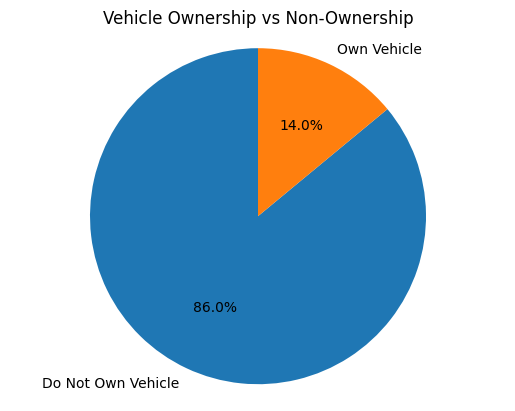

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

vehicle_column = '3. Vehicle Ownership'

# Ownership logic (BLANK = No vehicle)
df['Ownership_Status'] = df[vehicle_column].apply(
    lambda x: 'Own Vehicle' if pd.notna(x) else 'Do Not Own Vehicle'
)

# Count
ownership_counts = df['Ownership_Status'].value_counts()

# Plot pie chart
plt.figure()
plt.pie(
    ownership_counts,
    labels=ownership_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Vehicle Ownership vs Non-Ownership')
plt.axis('equal')

plt.savefig(
    "Vehicle ownership.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [7]:
print(ownership_counts)


Ownership_Status
Do Not Own Vehicle    430
Own Vehicle            70
Name: count, dtype: int64


## Proportion of Owned Vehicle

/tmp/ipykernel_47/534748354.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  owners_df[vehicle_column] = owners_df[vehicle_column].str.strip()


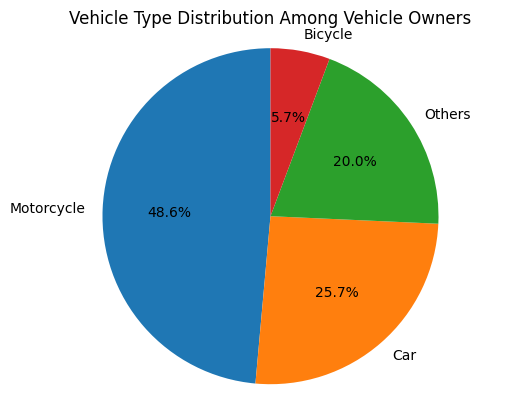

In [8]:
# Keep only people who own a vehicle
owners_df = df[df[vehicle_column].notna()]

# Clean vehicle type text
owners_df[vehicle_column] = owners_df[vehicle_column].str.strip()

# Count vehicle types
vehicle_type_counts = owners_df[vehicle_column].value_counts()

# Plot pie chart
plt.figure()
plt.pie(
    vehicle_type_counts,
    labels=vehicle_type_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Vehicle Type Distribution Among Vehicle Owners')
plt.axis('equal')
plt.savefig(
    "Propportion of Vehicle ownership.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show() 

In [9]:
vehicle_type_counts

3. Vehicle Ownership
Motorcycle    34
Car           18
Others        14
Bicycle        4
Name: count, dtype: int64

## Origin Destination Matrix Analysis

In [10]:
df = pd.read_excel("/kaggle/input/od-mrt-station-21-dec-2025/OD_MRT Station.xlsx")
print(df.columns.tolist())


['Origin MRT Station Cleaned', 'Destination MRT Station Cleaned']


In [11]:
df.columns.tolist() 

['Origin MRT Station Cleaned', 'Destination MRT Station Cleaned']

In [13]:
od_place_counts = (
    df.groupby(['Origin MRT Station Cleaned', 'Destination MRT Station Cleaned'])
      .size()
      .reset_index(name="Trip Count")
      .sort_values("Trip Count", ascending=False) 
)


od_place_counts["Percentage (%)"] = (
    od_place_counts["Trip Count"] / od_place_counts["Trip Count"].sum() * 100
).round(2)

od_place_counts.head() 

,Origin MRT Station Cleaned,Destination MRT Station Cleaned,Trip Count,Percentage (%)
43,Mirpur 11,Uttara North,17,3.4
45,Motijheel,Mirpur 11,16,3.2
44,Mirpur 11,Uttara South,14,2.8
91,Uttara North,Motijheel,14,2.8
92,Uttara North,Pallabi,14,2.8


In [20]:
od_place_counts.to_excel("OD_MRT Station.xlsx",
                 index=False
)

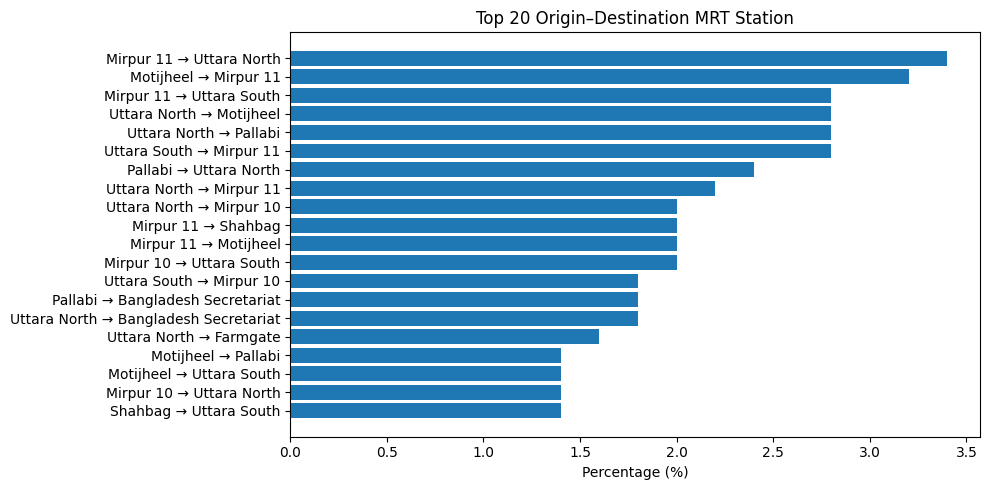

In [23]:
import matplotlib.pyplot as plt

# DEFINE how many top OD pairs you want
top_n = 20

# Select top OD pairs
od_top = od_place_counts.head(top_n)

plt.figure(figsize=(10,5))
plt.barh(
    od_top['Origin MRT Station Cleaned'] + " → " + od_top['Destination MRT Station Cleaned'],
    od_top["Percentage (%)"]
)

plt.xlabel("Percentage (%)")
plt.title(f"Top {top_n} Origin–Destination MRT Station")

plt.gca().invert_yaxis()   # highest on top
plt.tight_layout()

# SAVE FIGURE
plt.savefig(
    "OD_MRT Station.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show() 

In [ ]:
# SAVE FIGURE
plt.savefig(
    "Top_OD_Place_Pairs_Percentage.png",
    dpi=300,
    bbox_inches="tight"
)

## Selected ORIGIN MRT Station

In [13]:
selected_origins = [
    "Mirpur 11",
    "Pallabi",
    "Uttara North",
    "Uttara South",
    "Uttara Center"
]

od_place_counts = (
    df.groupby(
        ["Origin MRT Station Cleaned", "Destination MRT Station Cleaned"]
    )
    .size()
    .reset_index(name="Trip Count")
)

od_place_counts = od_place_counts[
    od_place_counts["Origin MRT Station Cleaned"].isin(selected_origins)
].sort_values("Trip Count", ascending=False)

od_place_counts["Percentage (%)"] = (
    od_place_counts["Trip Count"] / od_place_counts["Trip Count"].sum() * 100
).round(2)

od_place_counts

,Origin MRT Station Cleaned,Destination MRT Station Cleaned,Trip Count,Percentage (%)
43,Mirpur 11,Uttara North,17,5.52
44,Mirpur 11,Uttara South,14,4.55
104,Uttara South,Mirpur 11,14,4.55
91,Uttara North,Motijheel,14,4.55
92,Uttara North,Pallabi,14,4.55
...,...,...,...,...
52,Pallabi,Bijoy Sarani,1,0.32
41,Mirpur 11,Shawrapara,1,0.32
107,Uttara South,Shahbag,1,0.32
94,Uttara North,Shawrapara,1,0.32
